<style>
.jp-RenderedMarkdown, .rendered_html { font-family: Arial, Helvetica, sans-serif; font-size: 15px; line-height: 1.55; }
.jp-RenderedMarkdown h1, .rendered_html h1 { font-size: 24px; font-weight: 700; }
.jp-RenderedMarkdown h2, .rendered_html h2 { font-size: 20px; font-weight: 650; }
.jp-RenderedMarkdown h3, .rendered_html h3 { font-size: 17px; font-weight: 600; }
.jp-RenderedMarkdown p, .jp-RenderedMarkdown li, .rendered_html p, .rendered_html li { font-size: 15px; }
.jp-RenderedMarkdown code, .rendered_html code { font-size: 13px; }
</style>


# MeridianAI — Data Cleaning and Exploratory Data Analysis

# Notebook 02 – Data Cleaning and Exploratory Data Analysis

## Objective

The objective of this notebook is to clean the raw transactional dataset and perform exploratory data analysis (EDA) to understand customer purchasing behavior.

The notebook performs:

- Missing value handling
- Duplicate removal
- Data type conversion
- Invalid transaction removal
- Feature engineering
- Exploratory visualizations
- Customer-level aggregation

The cleaned dataset generated in this notebook will be used for customer segmentation and predictive analytics.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from datetime import datetime

In [2]:
df = pd.read_csv("../data/raw/online_retail_II.csv")

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.shape

(1067371, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 136.6 MB


In [6]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Drop Missing Values

In [7]:
df = df.dropna(subset=['Customer ID'])

Drop Duplicate values

In [8]:
df = df.drop_duplicates()

Convert plain text into real datetime format

In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

Remove Negative Quantities

In [12]:
df = df[df['Quantity'] > 0]

Remove invalid prices

In [13]:
df = df[df['Price'] > 0]

In [14]:
df['TotalAmount'] = df['Quantity'] * df['Price']

Check if Total Amount was created and if it is equal to the product of quantity and price

In [15]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


Create Year column

In [16]:
df['Year'] = df['InvoiceDate'].dt.year

Create Month column


In [17]:
df['Month'] = df['InvoiceDate'].dt.month

Create Day column 


In [18]:
df['Day'] = df['InvoiceDate'].dt.day

Create Hour column

In [19]:
df['Hour'] = df['InvoiceDate'].dt.hour

Check 

In [20]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Year,Month,Day,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,7


EXPLORATORY DATA ANALYSIS (EDA)

In [21]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,TotalAmount,Year,Month,Day,Hour
count,779425.000000,779425,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000
mean,13.489370,2011-01-03 01:44:42.593476,3.218488,15320.360461,22.291823,2010.432051,7.417059,15.390961,12.791884
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000,2009.000000,1.000000,1.000000,6.000000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000,4.950000,2010.000000,5.000000,8.000000,11.000000
50%,6.000000,2010-12-02 14:09:00,1.950000,15247.000000,12.480000,2010.000000,8.000000,15.000000,13.000000
75%,12.000000,2011-08-01 13:44:00,3.750000,16794.000000,19.800000,2011.000000,11.000000,23.000000,14.000000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,20.000000
std,145.855814,NaN,29.676140,1695.692775,227.427075,0.568385,3.422319,8.657939,2.294182


Find the Top 10 Countries with most transactions

In [22]:
df['Country'].value_counts().head(10)

Country
United Kingdom    700388
Germany            16432
EIRE               15565
France             13511
Netherlands         5085
Spain               3662
Belgium             3055
Switzerland         3005
Portugal            2356
Australia           1789
Name: count, dtype: int64

Visualize the above data

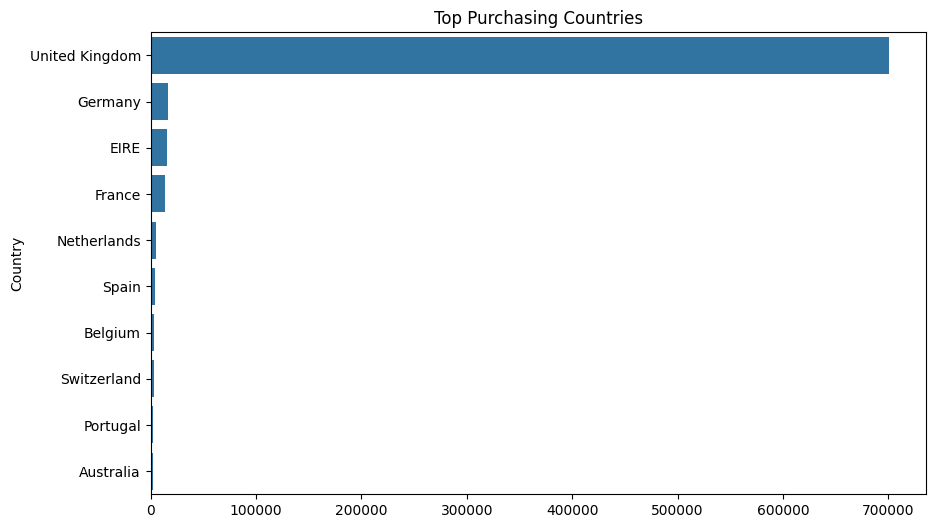

In [23]:
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top Purchasing Countries")

plt.show()

Create monthly sales

In [24]:
monthly_sales = df.groupby('Month')['TotalAmount'].sum()

Plot sales trend


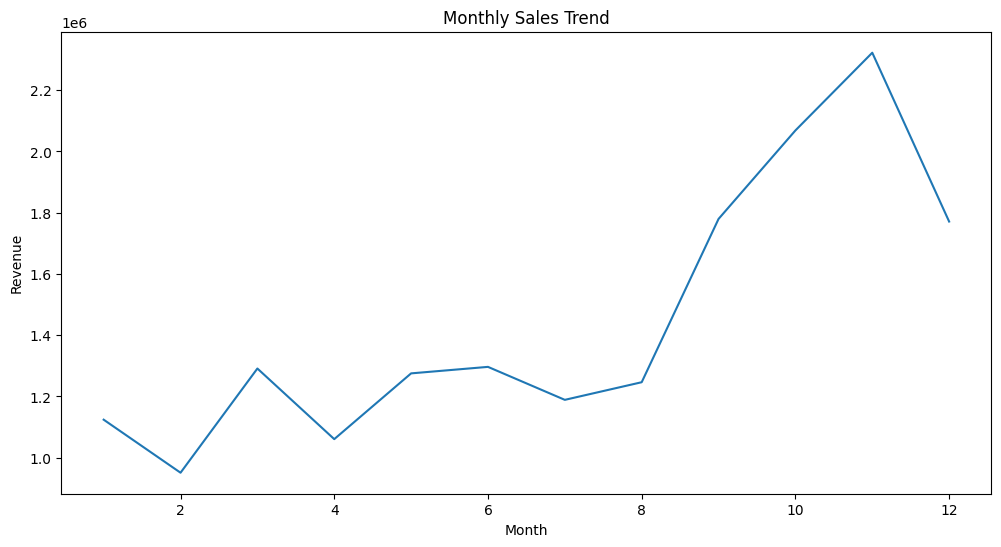

In [25]:
plt.figure(figsize=(12,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

Create customer dataframe


In [26]:
customer_df = df.groupby('Customer ID').agg({
    'Invoice': 'nunique',
    'Quantity': 'sum',
    'TotalAmount': 'sum',
    'InvoiceDate': 'max'
}).reset_index()

Rename Columns

In [27]:
customer_df.columns = [
    'CustomerID',
    'TotalTransactions',
    'TotalQuantity',
    'TotalSpent',
    'LastPurchaseDate'
]

Check

In [28]:
customer_df.head()

,CustomerID,TotalTransactions,TotalQuantity,TotalSpent,LastPurchaseDate
0,12346.0,12,74285,77556.46,2011-01-18 10:01:00
1,12347.0,8,2967,4921.53,2011-12-07 15:52:00
2,12348.0,5,2714,2019.40,2011-09-25 13:13:00
3,12349.0,4,1624,4428.69,2011-11-21 09:51:00
4,12350.0,1,197,334.40,2011-02-02 16:01:00


RFM ANALYSIS (Recency, frequency, Monetary)

Create Reference Date ( to find latest purchase date in the entire dataset)

In [29]:
reference_date = customer_df['LastPurchaseDate'].max()

Create recency (to find out how many days since the customer last purchased something)

In [30]:
customer_df['Recency'] = (
    reference_date - customer_df['LastPurchaseDate']
).dt.days

Create frequency ( to check how frequently a customer purchases)

In [31]:
customer_df['Frequency'] = customer_df['TotalTransactions']

Create Monetary ( to see the total money spent)

In [32]:
customer_df['Monetary'] = customer_df['TotalSpent']

Check final RFM Data

In [33]:
customer_df.head()

,CustomerID,TotalTransactions,TotalQuantity,TotalSpent,LastPurchaseDate,Recency,Frequency,Monetary
0,12346.0,12,74285,77556.46,2011-01-18 10:01:00,325,12,77556.46
1,12347.0,8,2967,4921.53,2011-12-07 15:52:00,1,8,4921.53
2,12348.0,5,2714,2019.40,2011-09-25 13:13:00,74,5,2019.40
3,12349.0,4,1624,4428.69,2011-11-21 09:51:00,18,4,4428.69
4,12350.0,1,197,334.40,2011-02-02 16:01:00,309,1,334.40


Create Spending Distribution Graph

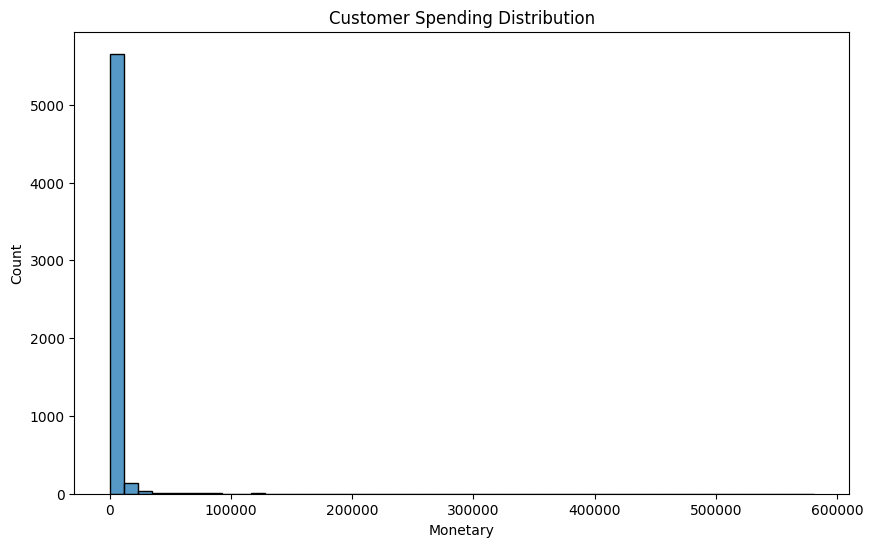

In [34]:
plt.figure(figsize=(10,6))

sns.histplot(
    customer_df['Monetary'],
    bins=50
)

plt.title("Customer Spending Distribution")

plt.show()

Visualize Purchase Frequency


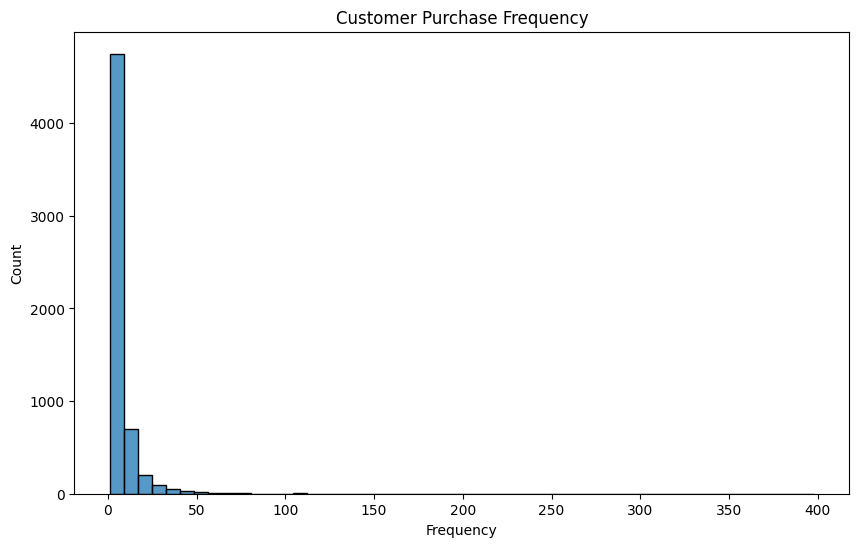

In [35]:
plt.figure(figsize=(10,6))

sns.histplot(
    customer_df['Frequency'],
    bins=50
)

plt.title("Customer Purchase Frequency")

plt.show()

Create an Outlier Plot

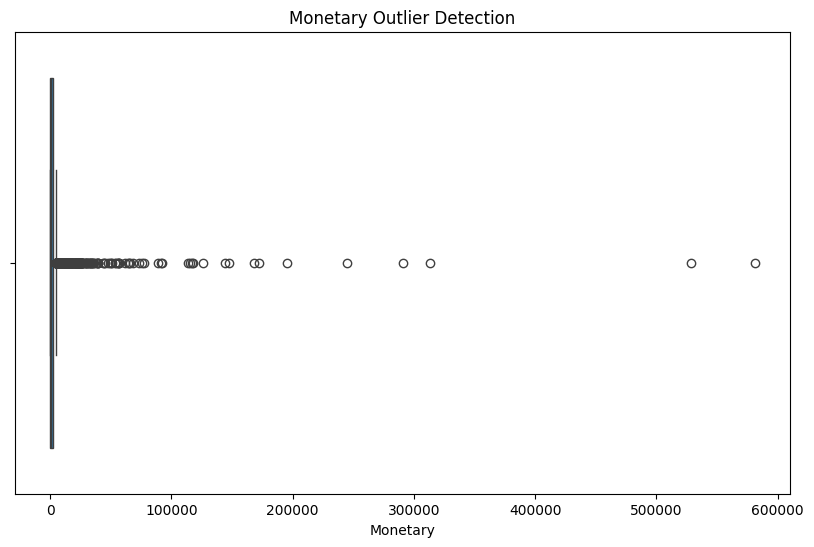

In [36]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=customer_df['Monetary']
)

plt.title("Monetary Outlier Detection")

plt.show()

RFM Correlation Matrix

In [37]:
corr = customer_df[
    ['Recency', 'Frequency', 'Monetary']
].corr()

Heatmap


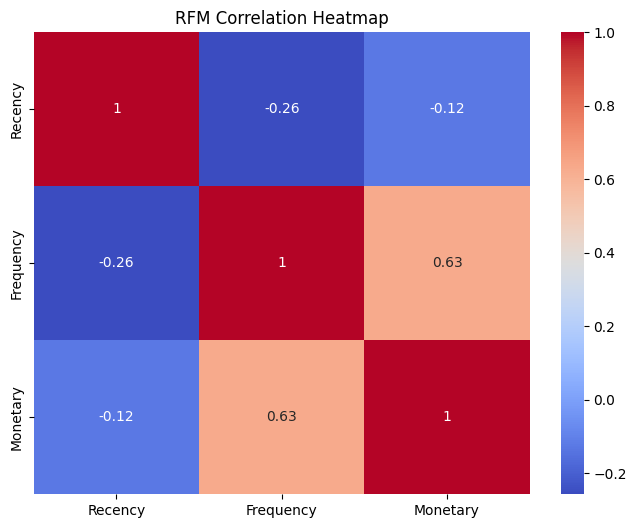

In [38]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("RFM Correlation Heatmap")

plt.show()

Save Cleaned Customer Data

In [39]:
customer_df.to_csv(
    "../data/processed/customer_features.csv",
    index=False
)

# Business Conclusion

After preprocessing and exploratory analysis, the dataset is transformed into a reliable customer-level dataset suitable for machine learning.

Key observations include:

- Invalid transactions were successfully removed.
- Missing customer identifiers were handled appropriately.
- Time-based features such as Year, Month, Day, and Hour were engineered.
- Customer purchasing behaviour shows significant variation across spending and purchase frequency.
- Customer aggregation provides Recency, Frequency, Monetary, and CustomerScore features which form the foundation for downstream segmentation and churn prediction.

The cleaned dataset is exported for use in the customer segmentation notebook.